# Analyze deconvolved gene expression

In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [199]:
from pipeline.expression_analysis import ExpressionAnalysis

In [201]:
output_directory = 'output/prototype_pipeline_subset/'
analysis = ExpressionAnalysis(output_directory)

In [206]:
analysis.deconvolved_genes_F.head()

,0,1,2,3,4,5,6,7,8,9,...,139,140,141,142,143,144,145,146,147,148
YLR301W,7.380548,7.472216,7.564129,7.652651,7.736641,7.814936,7.883699,7.939598,7.978192,7.995357,...,7.713511,7.710919,7.708265,7.705566,7.702903,7.700358,7.698020,7.695976,7.694211,7.380548
YPL094C,7.882542,7.848212,7.813169,7.779435,7.747679,7.718598,7.694234,7.676320,7.667278,7.669330,...,7.586816,7.572130,7.557170,7.542201,7.527542,7.513483,7.500210,7.487852,7.476442,7.882542
YLR092W,5.519916,5.374543,5.219578,5.057304,4.887897,4.711005,4.531712,4.355629,4.187518,4.032105,...,3.847398,3.817369,3.773266,3.715572,3.644671,3.561176,3.465895,3.359615,3.244115,5.519916
YBR046C,5.829210,5.945749,6.062994,6.180331,6.296598,6.410479,6.522529,6.633668,6.743293,6.851112,...,4.781844,4.747812,4.714312,4.681733,4.651449,4.624699,4.603071,4.588032,4.579088,5.829210
YHR028C,7.156002,7.106190,7.054791,7.005384,6.959217,6.917643,6.884010,6.861041,6.852861,6.863213,...,6.303680,6.296964,6.290084,6.283082,6.276173,6.269565,6.263491,6.258173,6.253572,7.156002


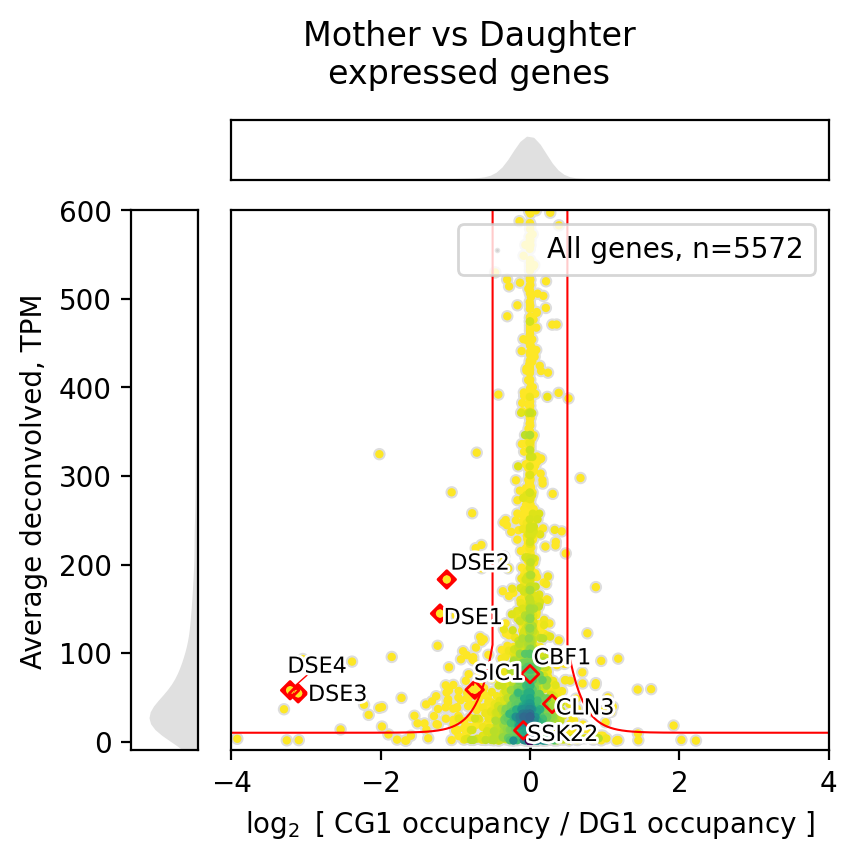

In [229]:
analysis.plot_volcano_cg1_dg1()

In [232]:
from src.config import load_default_expression_configs

config1, config2 = load_default_expression_configs()
_ = config1.calculate_H()

In [317]:
from src.deconvolution_solver import DeconvolutionSolver
from src.gene_expression import load_gene_expression

g = load_gene_expression('RPL2A', replicate=1)

gene_expression = g
deconvolution_solver = DeconvolutionSolver(config1, g=gene_expression, H=config1.H, 
    gamma=0.1, kappa=1.0, obj_error_mode='additive')


In [318]:
deconvolution_solver.deconvolve()

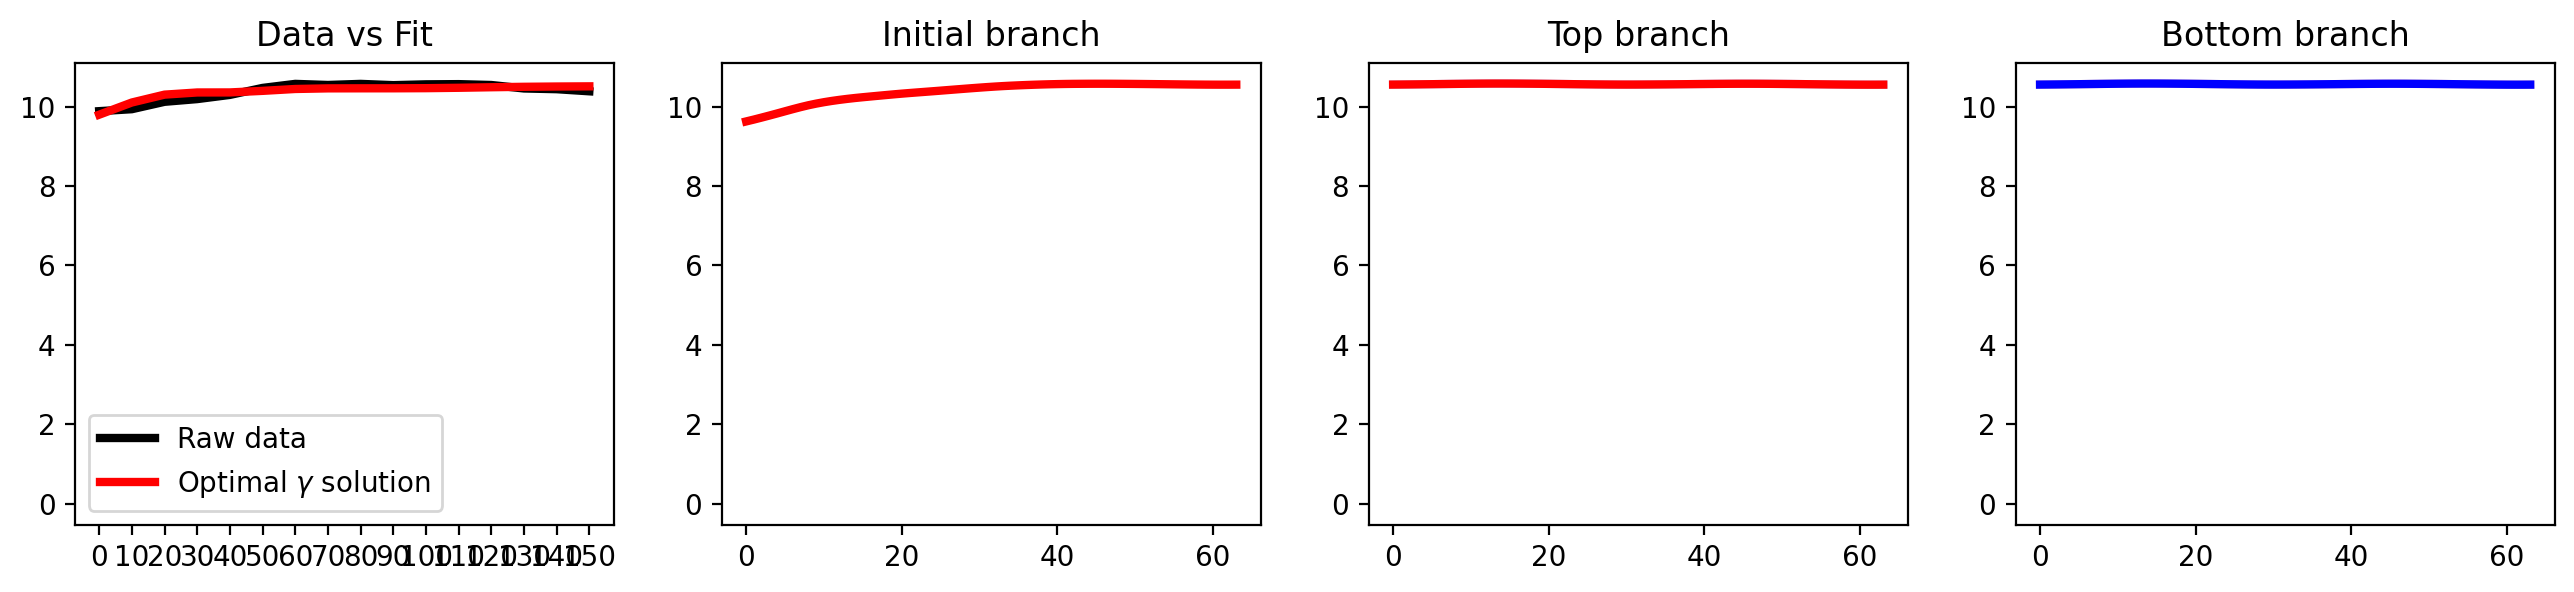

In [319]:
deconvolution_solver.plot_fit()